In [1]:
from scripts.synthetic_gap import *
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.interpolate import PchipInterpolator

from scripts.gap_sampler import sample_gaps

from scripts.score_method import score_method

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

In [2]:
STATION_LOCATIONS = {
    "CB01": {"latitude": 30.4193, "longitude": -98.8046},
    "CB04": {"latitude": 30.4600, "longitude": -98.9407},
    "CB06": {"latitude": 30.4421, "longitude": -98.8427},
    "CB07": {"latitude": 30.4376, "longitude": -98.8059},
    "CB09": {"latitude": 30.4283, "longitude": -98.8065},
    "CB10": {"latitude": 30.4298, "longitude": -98.7792},
    "CB15": {"latitude": 30.4319, "longitude": -98.8133},
    "CB19": {"latitude": 30.4327, "longitude": -98.8583},
    "CB20": {"latitude": 30.4151, "longitude": -98.8025},
    "CB25": {"latitude": 30.4175, "longitude": -98.8542},
    "CB26": {"latitude": 30.4218, "longitude": -98.7839},
    "CB27": {"latitude": 30.43154, "longitude": -98.860405},
    "CB31": {"latitude": 30.41932, "longitude": -98.80461},
    "CB32": {"latitude": 30.4613, "longitude": -98.8451},
    "CB33": {"latitude": 30.4487, "longitude": -98.848},
    "FD02": {"latitude": 30.2456, "longitude": -98.6988},
    "FD03": {"latitude": 30.4175, "longitude": -98.8542},
    "FD08": {"latitude": 30.2897,"longitude": -98.7462},
    "FD11": {"latitude": 30.2381,"longitude": -98.7701},
    "FD12": {"latitude": 30.2383,"longitude": -98.7037},
    "FD13": {"latitude": 30.2318,"longitude": -98.7084},
    "FD14": {"latitude": 30.2834,"longitude": -98.6864},
    "FD16": {"latitude": 30.3072,"longitude": -98.7703},
    "FD17": {"latitude": 30.2317,"longitude": -98.7685},
    "FD18": {"latitude": 30.2108,"longitude": -98.8331},
    "FD21": {"latitude": 30.2501,"longitude": -98.7069},
    "FD22": {"latitude": 30.2836,"longitude": -98.7417},
    "FD23": {"latitude": 30.2754,"longitude": -98.7268},
    "FD24": {"latitude": 30.2456,"longitude": -98.6988},
    "FD28": {"latitude": 30.2022,"longitude": -98.6543},
    "FD29": {"latitude": 30.2534,"longitude": -98.699},
    "FD30": {"latitude": 30.2492,"longitude": -98.6995},
    "WC05": {"latitude": 30.4319, "longitude": -98.8133}
}

print(len(STATION_LOCATIONS), "stations in STATION_LOCATIONS")

33 stations in STATION_LOCATIONS


# **Random Sampler**

In [3]:
# --- draw a random sample of synthetic SWC gaps across all stations ---

# ------------------------- knobs -------------------------
DATA_DIR = "prewashed_data"   # path to the prewashed station csvs
N_GAPS  = 500    # how many synthetic gaps to draw
SEED    = 8      # master seed, for a reproducible sample

COLUMN  = ["SWC_5", "SWC_10", "SWC_20", "SWC_50"]   # soil moisture only, for now.
                      # (None now means ANY measurement column — Ppt and T_* too —
                      # so we pin the SWC menu; "SWC_50" would fix one depth)

LENGTHS = ["1D","2D","3D","4D","5D","6D"]    # the exact gap lengths to draw;
                  # None -> draw lengths that match the DURATIONS of real gaps in
                  # the data (durations only — every sampled gap is synthetic,
                  # punched into a fully clean stretch)

STRATA  = True    # True -> split N_GAPS evenly across the distinct lengths;
                  # False -> draw each gap's length from the pool at random

RAIN_FRAC = 0.5     # None -> don't control rain; or a fraction like 0.5 -> that share
                  # of gaps must contain rain, enforced at every distinct gap length

CONTEXT = "1D"   # data kept on each side of each gap

POOL_MAX = "8D"  # with LENGTHS=None, only durations shorter than this are matched

MET = False       # False -> soil stations; True -> the *_met stations
# ----------------------------------------------------------

samples = sample_gaps(DATA_DIR, n_gaps=N_GAPS, seed=SEED, column=COLUMN,
                      lengths=LENGTHS, strata=STRATA, rain_frac=RAIN_FRAC,
                      context=CONTEXT, pool_max=POOL_MAX, met=MET)

500 gaps drawn (765 attempts)
rain      False  True 
length_h              
24           42     42
48           42     42
72           41     42
96           42     41
120          41     42
144          42     41


# **Imputation Methods**

In [4]:
# --- baselines carried over from the short-gap study ---
def impute_locf(gapped, column):
    """Fill NaNs with the most recent value before the gap."""
    return gapped[column].ffill()

def impute_nearest(gapped, column):
    """Fill each NaN with whichever valid observation is closer in time."""
    s = gapped[column]
    t = s.index.to_series()
    t_prev = t.where(s.notna()).ffill()
    t_next = t.where(s.notna()).bfill()
    use_next = (t_next - t) < (t - t_prev)
    return s.ffill().where(~use_next, s.bfill())

def impute_linear(gapped, column):
    """Fill NaNs in one column by linear interpolation against the time index."""
    return gapped[column].interpolate(method="time", limit_area="inside")

def impute_pchip(gapped, column):
    """Fill NaNs with monotone piecewise-cubic interpolation (scipy PCHIP via pandas)."""
    return gapped[column].interpolate(method="pchip", limit_area="inside")

scores_nearest = score_method(impute_nearest, samples, name="baseline — nearest")
scores         = score_method(impute_linear, samples, name="baseline — linear")
scores_pchip   = score_method(impute_pchip, samples, name="baseline — PCHIP")

baseline — nearest, 500 gaps (m3/m3)
overall: RMSE 0.0145   MAE 0.0099   bias +0.0005
length_bin  rain_in_gap  n   rmse    mae    bias
       24h        False 42 0.0032 0.0024  0.0003
       24h         True 42 0.0193 0.0127 -0.0012
       48h        False 42 0.0053 0.0042  0.0006
       48h         True 42 0.0156 0.0105 -0.0013
       72h        False 41 0.0042 0.0032 -0.0004
       72h         True 42 0.0293 0.0188  0.0078
       96h        False 42 0.0060 0.0050  0.0010
       96h         True 41 0.0189 0.0124 -0.0028
      120h        False 41 0.0057 0.0047  0.0012
      120h         True 42 0.0305 0.0196 -0.0010
      144h        False 42 0.0089 0.0069  0.0013
      144h         True 41 0.0276 0.0186  0.0006
baseline — linear, 500 gaps (m3/m3)
overall: RMSE 0.0117   MAE 0.0097   bias +0.0005
length_bin  rain_in_gap  n   rmse    mae    bias
       24h        False 42 0.0027 0.0023  0.0003
       24h         True 42 0.0159 0.0137 -0.0012
       48h        False 42 0.0029 0.0024  0.0

In [5]:
# --- cross-station donor ---
# Borrow the in-gap SHAPE of an alive neighbour (same depth), blended onto this
# gap's own edge values so level differences between stations cancel. Donors are
# ranked by correlation of hourly CHANGES, which drops the shared seasonal cycle
# (see neighbor_check.ipynb).
#
# donor_select="rank"    -> use the best-ranked alive donor(s)  (candidate 5 / 5b)
# donor_select="context" -> audition the top alive donors on the OBSERVED context
#                           around the gap: reconstruct the context rows with the
#                           same anchored transform and keep whoever does it best
#                           (candidate 5c). Ties and no-signal contexts fall back
#                           to the global rank order.
def make_impute_neighbor(data_dir="prewashed_data", n_donors=1, mask_samples=None,
                         donor_select="rank", m_candidates=10):
    data_dir = Path(data_dir)
    frames = {p.stem: pd.read_csv(p, index_col="Date", parse_dates=["Date"])
              for p in sorted(data_dir.glob("*.csv")) if not p.stem.endswith("_met")}
    depths = sorted({c for df in frames.values() for c in df.columns if c.startswith("SWC")})
    wide = {d: pd.DataFrame({st: df[d] for st, df in frames.items() if d in df.columns})
            for d in depths}
    # Donor ranking by increment correlation. To keep the benchmark leak-free,
    # pass mask_samples=samples: every synthetic answer window is then hidden
    # from its target station's column first, so the ranking is computed from
    # exactly the data the methods are allowed to see.
    rank = {}
    for d in depths:
        w = wide[d]
        if mask_samples is not None:
            w = w.copy()
            for smp in mask_samples:
                if smp["column"] == d and smp["station"] in w.columns:
                    w.loc[smp["answer"].index, smp["station"]] = np.nan
        c = w.diff().corr(min_periods=24 * 90)           # increment correlation
        c = c.mask(np.eye(len(c), dtype=bool))
        for st in c.columns:
            rank[(st, d)] = list(c[st].dropna().sort_values(ascending=False).index)

    def impute(gapped, column):
        s = gapped[column]
        out = s.copy()
        gap = s.index[s.isna()]
        if len(gap) == 0:
            return out
        left, right = s.loc[:gap[0]].dropna(), s.loc[gap[-1]:].dropna()
        if left.empty or right.empty:                    # unanchored -> plain interpolation
            return s.interpolate(method="time", limit_area="inside")
        tL, yL = left.index[-1], float(left.iloc[-1])
        tR, yR = right.index[0], float(right.iloc[0])

        # whose frame is this? the context values identify the station exactly
        w = wide[column]
        obs = s.dropna()
        matches = w.reindex(obs.index).eq(obs, axis=0).all()
        station = matches.idxmax() if matches.any() else None

        def anchored_fill(nb):
            """The donor's shape, blended onto this gap's own anchors."""
            donor = w[nb]
            wgt = (gap - tL) / (tR - tL)                 # 0 at left anchor -> 1 at right
            return (donor.loc[gap]
                    + (1 - wgt) * (yL - donor.loc[tL])
                    + wgt * (yR - donor.loc[tR]))

        def context_error(nb):
            """How well the same transform reconstructs the OBSERVED context rows."""
            errs = []
            for seg in (left, right):
                if len(seg) < 3:
                    continue                             # too short to judge on
                a, b = seg.index[0], seg.index[-1]
                donor = w[nb].loc[a:b]
                if donor.isna().any():
                    continue
                wgt = (seg.index - a) / (b - a)
                recon = (donor.loc[seg.index]
                         + (1 - wgt) * (float(seg.iloc[0]) - donor.loc[a])
                         + wgt * (float(seg.iloc[-1]) - donor.loc[b]))
                errs.append(float((recon - seg).abs().iloc[1:-1].mean()))
            return np.mean(errs) if errs else np.inf     # no verdict -> sink to the back

        # alive candidates, best global rank first
        want = n_donors if donor_select == "rank" else m_candidates
        alive = []
        for nb in rank.get((station, column), []):
            if w[nb].loc[tL:tR].isna().any():
                continue                                 # donor has a hole here
            alive.append(nb)
            if len(alive) == want:
                break
        if not alive:                                    # nobody alive -> plain interpolation
            return s.interpolate(method="time", limit_area="inside")

        if donor_select == "context":                    # audition on the context;
            alive = sorted(alive, key=context_error)     # stable sort -> ties keep rank order

        fills = [anchored_fill(nb) for nb in alive[:n_donors]]
        out.loc[gap] = sum(fills) / len(fills)
        return out

    return impute

impute_neighbor     = make_impute_neighbor(DATA_DIR, n_donors=1,   # best alive donor,
                                           mask_samples=samples)   # leak-free ranking
impute_neighbor3    = make_impute_neighbor(DATA_DIR, n_donors=3,   # mean of best three
                                           mask_samples=samples)
impute_neighbor_ctx = make_impute_neighbor(DATA_DIR, n_donors=1,   # context-picked donor
                                           mask_samples=samples, donor_select="context")

scores_neighbor     = score_method(impute_neighbor, samples, name="candidate 5 — cross-station donor")
scores_neighbor3    = score_method(impute_neighbor3, samples, name="candidate 5b — mean of 3 donors")
scores_neighbor_ctx = score_method(impute_neighbor_ctx, samples, name="candidate 5c — context-picked donor")

candidate 5 — cross-station donor, 500 gaps (m3/m3)
overall: RMSE 0.0094   MAE 0.0074   bias +0.0008
length_bin  rain_in_gap  n   rmse    mae    bias
       24h        False 42 0.0028 0.0022  0.0010
       24h         True 42 0.0141 0.0117  0.0007
       48h        False 42 0.0032 0.0027  0.0001
       48h         True 42 0.0134 0.0105  0.0017
       72h        False 41 0.0027 0.0020 -0.0007
       72h         True 42 0.0112 0.0082  0.0008
       96h        False 42 0.0035 0.0028  0.0004
       96h         True 41 0.0168 0.0128  0.0033
      120h        False 41 0.0023 0.0019  0.0001
      120h         True 42 0.0202 0.0158  0.0029
      144h        False 42 0.0036 0.0029 -0.0000
      144h         True 41 0.0190 0.0153 -0.0006
candidate 5b — mean of 3 donors, 500 gaps (m3/m3)
overall: RMSE 0.0082   MAE 0.0065   bias +0.0004
length_bin  rain_in_gap  n   rmse    mae    bias
       24h        False 42 0.0024 0.0020  0.0006
       24h         True 42 0.0136 0.0113  0.0005
       48h      

# **Graphics**

In [6]:
METHODS = {"Nearest": impute_nearest,
           "Linear": impute_linear, "PCHIP": impute_pchip,
           "Neighbor": impute_neighbor, "Nbr-ctx": impute_neighbor_ctx}

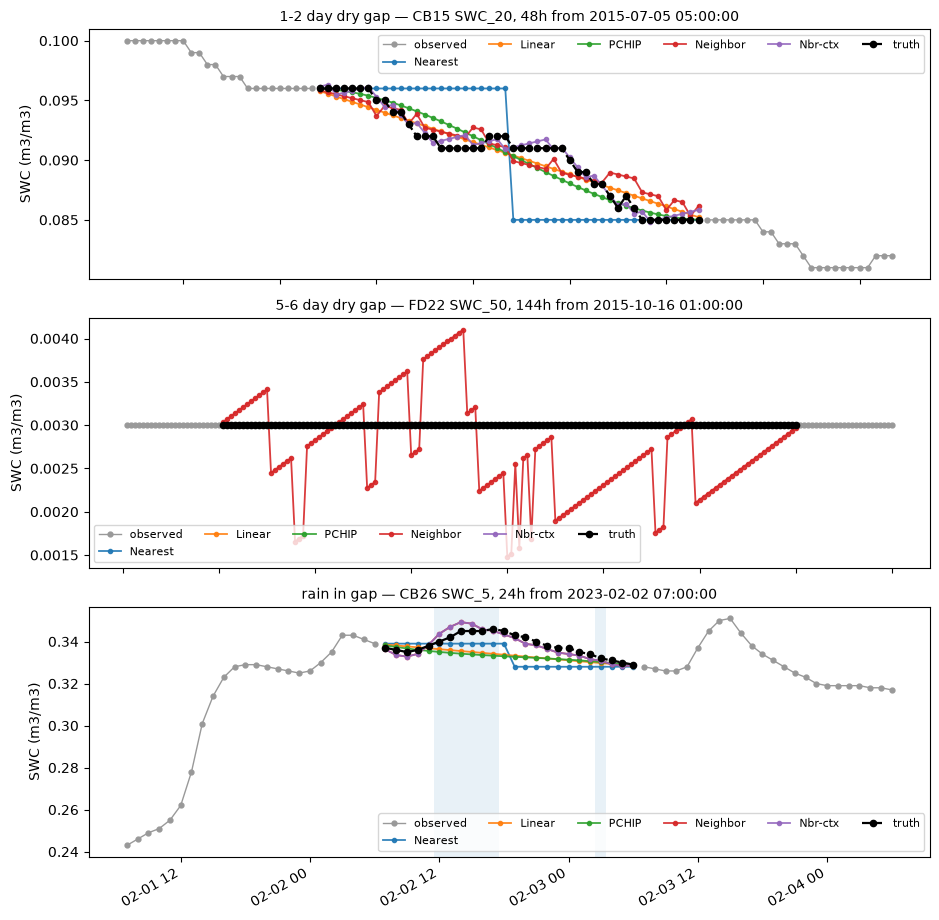

In [7]:
# --- demo: the four methods filling example gaps ---

_demo_rng = np.random.default_rng()      # unseeded -> a fresh random draw every run

def _pick(cond):
    """A randomly drawn sample index matching cond, else None."""
    hits = [i for i, s in enumerate(samples) if cond(s)]
    return int(_demo_rng.choice(hits)) if hits else None

examples = [
            ("1-2 day dry gap", _pick(lambda s: s["length_h"] <= 48 and not s["rain_in_gap"])),
            ("5-6 day dry gap", _pick(lambda s: s["length_h"] >= 120 and not s["rain_in_gap"])),
            ("rain in gap",     _pick(lambda s: s["rain_in_gap"]))]
examples = [(t, i) for t, i in examples if i is not None]

fig, axes = plt.subplots(len(examples), 1, figsize=(9.5, 3.1 * len(examples)), squeeze=False)
for ax, (title, i) in zip(axes[:, 0], examples):
    s = samples[i]
    col, win = s["column"], s["answer"].index
    obs = s["gapped"][col]
    # shade rainy hours in the window
    for t in win[s["gapped"].loc[win, "Ppt"].fillna(0).gt(0)]:
        ax.axvspan(t - pd.Timedelta("30min"), t + pd.Timedelta("30min"),
                   color="tab:blue", alpha=0.10, lw=0)
    ax.plot(obs.index, obs, "o-", color="0.6", ms=3.5, lw=1, label="observed")
    for name, fn in METHODS.items():
        ax.plot(win, fn(s["gapped"], col).loc[win], "-o", ms=3, lw=1.3, alpha=0.9, label=name)
    ax.plot(win, s["answer"][col], "k--o", ms=4.5, lw=1.6, label="truth", zorder=5)
    ax.set_title(f"{title} — {s['station']} {col}, {s['length_h']}h from {win[0]}", fontsize=10)
    ax.set_ylabel("SWC (m3/m3)")
    ax.legend(ncols=6, fontsize=8, loc="best")
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

In [8]:
order = ["Nearest", "Linear", "PCHIP", "Neighbor", "Nbr-ctx"]
all_scores = pd.concat([df.assign(method=m) for m, df in
                        [("Nearest", scores_nearest),
                         ("Linear", scores), ("PCHIP", scores_pchip),
                         ("Neighbor", scores_neighbor), ("Nbr-ctx", scores_neighbor_ctx)]],
                       ignore_index=True)

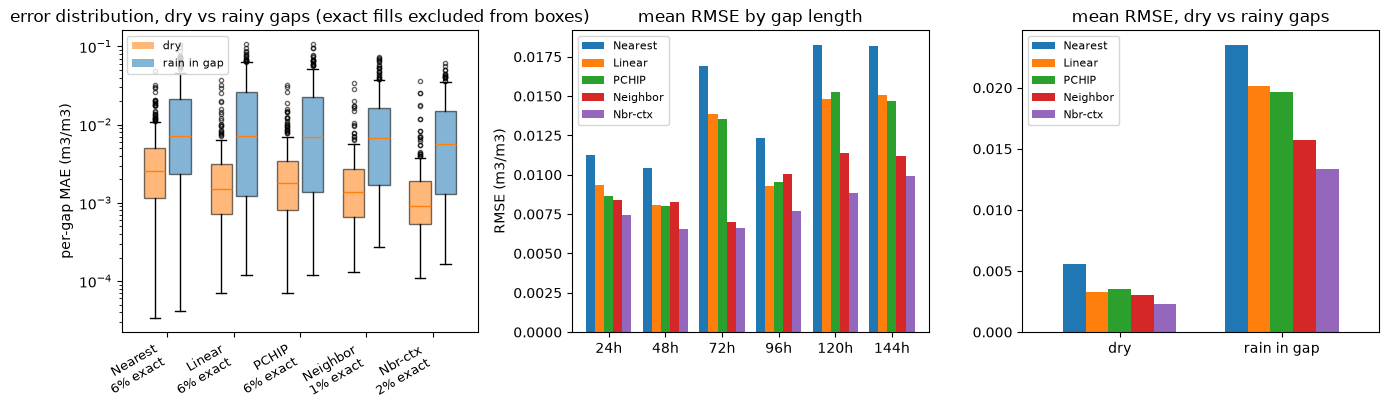

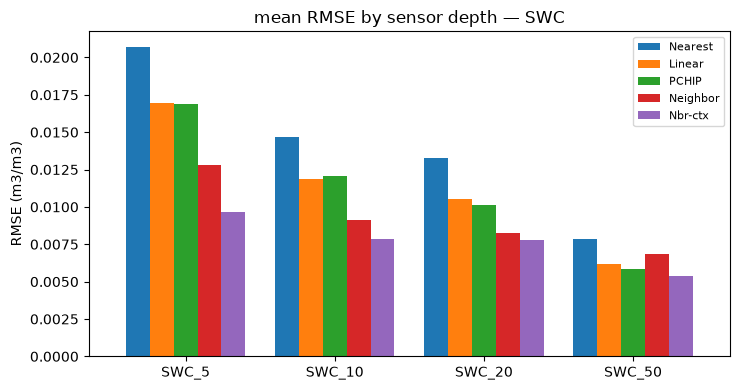

In [9]:
# --- error comparison across methods ---

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))

# 1) per-gap MAE distributions, dry and rain-in-gap side by side
#    (log scale; exact fills excluded from the boxes, their share shown below)
pos = np.arange(len(order))
groups = [("dry", ~all_scores["rain_in_gap"], "tab:orange", -0.19),
          ("rain in gap", all_scores["rain_in_gap"], "tab:blue", +0.19)]
for label, mask, color, off in groups:
    sub = all_scores[mask]
    if sub.empty:                       # e.g. RAIN_FRAC = 0 -> no rainy gaps drawn
        continue
    data = [sub.loc[(sub["method"] == m) & (sub["mae"] > 1e-9), "mae"] for m in order]
    bp = axes[0].boxplot(data, positions=pos + off, widths=0.32, patch_artist=True,
                         flierprops=dict(markersize=3, alpha=0.6))
    for b in bp["boxes"]:
        b.set_facecolor(color)
        b.set_alpha(0.55)
axes[0].set_xticks(pos)
# "exact" = matches the truth to floating-point noise. The donor blend's
# 3-term sum leaves ~1e-17 residues on flat stretches where linear's np.interp
# cancels bit-exactly, so a > 0 test would miscount the donor methods.
exact = [(all_scores.loc[all_scores["method"] == m, "mae"] <= 1e-9).mean() * 100
         for m in order]                     # exact fills are a WIN RATE, not an
axes[0].set_xticklabels([f"{m}\n{p:.0f}% exact"   # error: shown here, not in the boxes
                         for m, p in zip(order, exact)],
                        rotation=30, ha="right", fontsize=9)
axes[0].set_yscale("log")
axes[0].set_ylabel("per-gap MAE (m3/m3)")
axes[0].set_title("error distribution, dry vs rainy gaps (exact fills excluded from boxes)")
axes[0].legend(handles=[Patch(facecolor=c, alpha=0.55, label=l) for l, _, c, _ in groups],
               fontsize=8, loc="upper left")

# 2) mean RMSE by gap length
(all_scores.pivot_table(index="length_bin", columns="method", values="rmse", observed=False)
           .loc[:, order]
           .plot.bar(ax=axes[1], rot=0, width=0.8))
axes[1].set_title("mean RMSE by gap length")
axes[1].set_xlabel("")
axes[1].set_ylabel("RMSE (m3/m3)")
axes[1].legend(fontsize=8)

# 3) dry gaps vs rain-in-gap
piv = (all_scores.assign(rain=all_scores["rain_in_gap"].map({False: "dry", True: "rain in gap"}))
                 .pivot_table(index="rain", columns="method", values="rmse")
                 .loc[:, order])
piv.plot.bar(ax=axes[2], rot=0, width=0.7)
axes[2].set_title("mean RMSE, dry vs rainy gaps")
axes[2].set_xlabel("")
axes[2].legend(fontsize=8)

fig.tight_layout()
plt.show()

# methods by sensor depth — one chart per data type (SWC, T, ...) that has
# gaps at more than one depth in this sample
depth_scores = all_scores[all_scores["column"].str.contains("_")]     # e.g. SWC_5, T_20
for prefix in sorted(depth_scores["column"].str.split("_").str[0].unique()):
    sub = depth_scores[depth_scores["column"].str.startswith(prefix + "_")]
    if sub["column"].nunique() < 2:
        continue                                    # only one depth -> nothing to compare
    depths = sorted(sub["column"].unique(), key=lambda c: int(c.split("_")[1]))
    fig2, ax = plt.subplots(figsize=(7.5, 4))
    (sub.pivot_table(index="column", columns="method", values="rmse")
        .loc[depths, order]
        .plot.bar(ax=ax, rot=0, width=0.8))
    ax.set_title(f"mean RMSE by sensor depth — {prefix}")
    ax.set_xlabel("")
    ax.set_ylabel("RMSE (m3/m3)")
    ax.legend(fontsize=8)
    fig2.tight_layout()
    plt.show()